In [1]:
"""
Visualize embeddings from multiple files using UMAP.
First file defines the embedding space, other files are projected onto it.
"""
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from umap import UMAP
from matplotlib.patches import FancyBboxPatch, Rectangle
from matplotlib.lines import Line2D

# Add root to path
def find_root_path(path: str, word: str):
    parts = path.split(word, 1)
    return parts[0] + word if len(parts) > 1 else path

root_folder = Path(find_root_path(os.getcwd(), 'art_lang'))
sys.path.append(str(root_folder))

# Import functions from umap_analysis.py instead of redefining them
from rpod.embeddings.umap_analysis import (
    load_data,
    sample_by_behavior,  # Use this to sample k commands per behavior if needed
    create_text_encoder,
    extract_embeddings
)


In [ ]:
def visualize_multi_file_embeddings(projections_2d, all_behaviors, file_paths, markers, colors, 
                                     custom_embeddings_2d=None, custom_commands=None, save_path=None,
                                     cluster_metrics=None):
    """
    Visualize embeddings from multiple files.
    First file uses circles, subsequent files use different markers.
    Same colors for same behaviors across files.
    Custom commands are shown as black X markers.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Plot each file
    for file_idx, (projection, behaviors, file_path) in enumerate(zip(projections_2d, all_behaviors, file_paths)):
        marker = markers[file_idx] if file_idx < len(markers) else 'o'
        label_prefix = f"File {file_idx + 1}" if file_idx == 0 else f"File {file_idx + 1} (projected)"
        
        # Plot each behavior with its color
        for behavior_id in range(6):
            mask = behaviors == behavior_id
            if mask.sum() > 0:
                ax.scatter(
                    projection[mask, 0],
                    projection[mask, 1],
                    c=[colors[behavior_id]],
                    marker=marker,
                    label=f"{label_prefix} - Behavior {behavior_id}" if file_idx == 0 else None,
                    alpha=0.6 if file_idx == 0 else 0.7,
                    s=60 if file_idx == 0 else 48,
                    edgecolors='black' if file_idx == 0 else None,
                    linewidths=0.5 if file_idx == 0 else 0
                )
    
    # Plot custom commands as black X markers (on top)
    if custom_embeddings_2d is not None and custom_commands is not None:
        ax.scatter(
            custom_embeddings_2d[:, 0],
            custom_embeddings_2d[:, 1],
            c='black',
            marker='X',
            s=80,
            alpha=0.8,
            label='Custom Commands',
            edgecolors='black',
            linewidths=0.5,
            zorder=10  # Plot on top
        )
    
    ax.set_xlabel("UMAP Dimension 1", fontsize=16)
    ax.set_ylabel("UMAP Dimension 2", fontsize=16)
    # ax.set_title("Embedding Visualization", fontsize=22)
    ax.tick_params(axis='both', labelsize=16)
    
    # Create custom legend: show markers for files, colors for behaviors
    legend_elements = []
    
    # Add file markers
    # for file_idx, file_path in enumerate(file_paths):
    #     marker = markers[file_idx] if file_idx < len(markers) else 'o'
    #     file_name = Path(file_path).stem
    #     label = "Training Data" if file_idx == 0 else "Validation Data"
    #     legend_elements.append(Line2D([0], [0], marker=marker, color='w', 
    #                                  markerfacecolor='gray', markersize=10, 
    #                                  label=label,
    #                                 #  label=f"File {file_idx + 1}: {file_name}",
    #                                  markeredgecolor='black', markeredgewidth=1))
    
    # Add custom commands to legend if present
    if custom_embeddings_2d is not None and custom_commands is not None:
        legend_elements.append(Line2D([0], [0], marker='X', color='w',
                                     markerfacecolor='black', markersize=10,
                                     label='Custom Commands',
                                     markeredgecolor='black', markeredgewidth=1))
    
    # legend_elements.append(Line2D([0], [0], color='w', label=''))  # Spacer
    
    # Add behavior colors
    for behavior_id in range(6):
        legend_elements.append(Line2D([0], [0], marker='o', color='w',
                                     markerfacecolor=colors[behavior_id], 
                                     markersize=10, label=f"{behavior_id} (train)"))
    
        legend_elements.append(Line2D([0], [0], marker='^', color='w',
                                     markerfacecolor=colors[behavior_id], 
                                     markersize=10, label=f"{behavior_id} (test)"))
    
    ax.legend(handles=legend_elements, ncol=6, fontsize=13, loc='upper center', bbox_to_anchor=(0.5, -0.1), 
              columnspacing=0.5,   # ↓ space between columns
                handletextpad=0.3,   # ↓ marker–text gap
                handlelength=1.2,    # ↓ marker length
                )

    if cluster_metrics:
        behavior_keys = sorted([k for k in cluster_metrics.keys() if k.isdigit()], key=lambda x: int(x))
        table_width = min(0.6, 0.08 * len(behavior_keys) + 0.08)
        table_height = 0.10
        table_left = 0.05
        table_bottom = 0.05

        metrics_box = FancyBboxPatch(
            (table_left, table_bottom),
            table_width,
            table_height,
            boxstyle="round,pad=0.02",
            transform=ax.transAxes,
            linewidth=1,
            edgecolor='gray',
            facecolor='white',
            alpha=0.9,
            zorder=5
        )
        ax.add_patch(metrics_box)

        ax.text(
            table_left + 0.21,
            table_bottom + table_height + 0.05,
            "Silhouette Scores",
            transform=ax.transAxes,
            fontsize=14,
            # fontweight='bold',
            va='top',
            ha='left',
            zorder=6
        )

        col_width = table_width / len(behavior_keys)
        color_box_height = table_height * 0.15

        for idx, behavior_key in enumerate(behavior_keys):
            behavior_id = int(behavior_key)
            score = cluster_metrics[behavior_key]
            x_start = table_left + col_width * idx
            x_center = x_start + col_width / 2

            color_box_width = min(0.04, col_width * 0.15)
            color_box = Rectangle(
                (x_center - color_box_width / 2, table_bottom + table_height * 0.45),
                color_box_width,
                color_box_height,
                transform=ax.transAxes,
                facecolor=colors[behavior_id],
                edgecolor='black',
                linewidth=0.5,
                zorder=6
            )
            ax.add_patch(color_box)

            ax.text(
                x_center,
                table_bottom + table_height * 0.85,
                f"B{behavior_id}",
                transform=ax.transAxes,
                ha='center',
                va='center',
                fontsize=14,
                zorder=6
            )

            ax.text(
                x_center,
                table_bottom + table_height * 0.18,
                f"{score:.2f}",
                transform=ax.transAxes,
                ha='center',
                va='center',
                fontsize=13,
                zorder=6
            )

        accuracy_box = FancyBboxPatch(
            (0.03, 0.92),
            0.34,
            0.04,
            boxstyle="round,pad=0.02",
            transform=ax.transAxes,
            linewidth=1,
            edgecolor='gray',
            facecolor='white',
            alpha=0.9,
            zorder=5
        )
        ax.add_patch(accuracy_box)
        nn_acc = cluster_metrics.get("nn_accuracy", 0.00)
        ax.text(
            0.2,
            0.94,
            f"1-Nearest-Neighbour Accuracy = {nn_acc*100:.2f}%",
            transform=ax.transAxes,
            fontsize=14,
            va='center',
            ha='center',
            zorder=6
        )

    ax.grid(True, alpha=0.3)
    # plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved visualization to: {save_path}")
    
    plt.show()


In [50]:
# ========== HYPERPARAMETERS ==========
FILE_TYPE = "TORCH"  # (.pth = TORCH, .jsonl = JSON)

# List of files to visualize (first one defines the embedding space)
file_paths = [
    "rpod/dataset/torch/v08/annotation_texts.pth",  # First file: defines space (circles)
    "rpod/dataset/torch/v08/annotation_texts_val.pth",     # Second file: projected (triangles)
]

# Sampling settings (matches umap_analysis.py - always samples)
k_per_behavior = 100  # Number of commands to sample per behavior

# Encoder settings
encoder_mode = "FROZEN"  # "TRAINED" or "FROZEN"
checkpoint_path = "rpod/decision_transformer/saved_files/checkpoints/v08_w3/text_adapter.pth"
model_name = "distilbert-base-uncased"
out_dim = 384
max_tokens = 50
batch_size = 32
random_seed = 42

# Device settings
device = "auto"  # "auto", "cuda", or "cpu"
if device == "auto":
    device = "cuda" if torch.cuda.is_available() else "cpu"

# UMAP settings
umap_n_neighbors = 15
umap_min_dist = 0.5
umap_n_components = 2

# Visualization settings
markers = ['o', '^', 's', 'D', 'v', 'p']
colors = plt.cm.tab10(np.linspace(0, 1, 6))
# =====================================

In [51]:
show_custom_commands = True # To check where the new commands fall among the behaviors

custom_commands = [
    # Add test commands here
    # "Navigate around the target in a circular pattern",
    # "Approach the target slowly and carefully",
    # "Commence -V-bar path for 2.2 orbits; circumnavigate by 3.7 orbits; stay in circumnavigation.",
    # "Commence -V-bar path for 2.2 orbits; circumnavigate by 4.9 orbits.",
    # "Commence -V-bar path for 2.2 orbits; circumnavigate by 6.1 orbits; stay there.",
    # "V-bar path commence, 2.2 orbits, 3.7 orbits, circumnavigation, approach, recede.", 
    # "Achieve -V-bar approach; circumnavigate and create E/I separation in 1.0 orbits; ; maintain RN-plane separation through +V-bar.",
    # 'Engage approach to target from -V-bar for 2.0 orbits; circumnavigate and create E/I separation in 4.0 orbits; move back along -V-bar while maintaining separation.'
    # "Approach from -V-bar for 3.7 orbits; circumnavigate until 4.0 orbits; then move +V-bar.",
    # "Perform the approach in a 4.9 orbits spiral; after target acquisition, proceed with circumnavigation safely.",
    # "Achieve stability at -V-bar; configure for E/I separation in 0.9 orbits with circumnavigation, then execute delta-a until 3.7 orbits."

    # Completely OOD text commands
    # "Just go there somhow, that's all.",
    # "Hello World!",
    # "I am a fan of space rendezvous.",
    # "syerghjfjvb fdfrdrfdfhdjxyrfgbs"
]

Using cached data (no recomputation needed)

show_custom_commands is True but custom_commands list is empty.

Creating visualization...


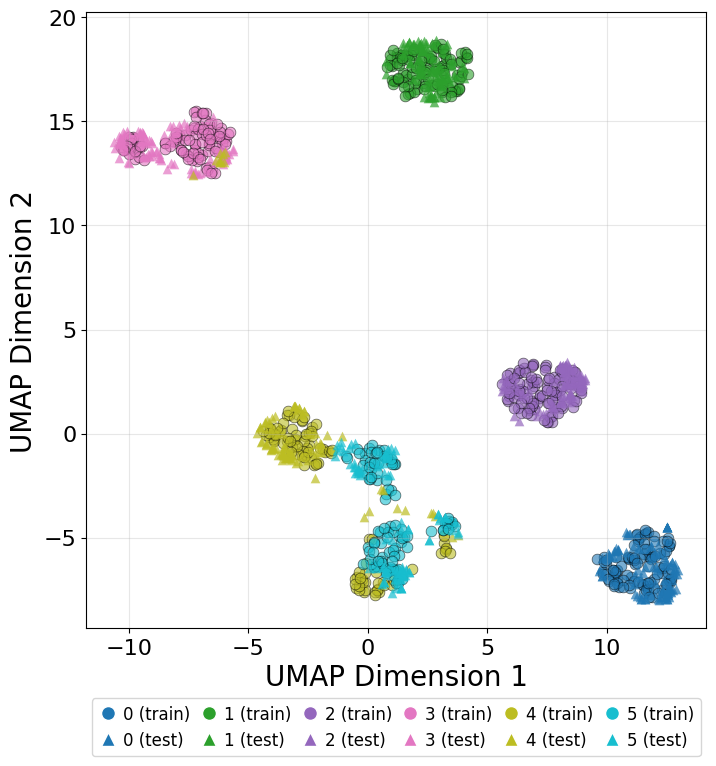

Visualization completed!


In [52]:
# Check if we need to recompute main data (only first time)
if 'reducer' not in globals() or 'encoder' not in globals() or 'all_embeddings' not in globals():
    print("First run: Loading files and fitting UMAP...")
    
    # Load all files and extract embeddings
    all_text_commands = []
    all_behaviors = []
    all_embeddings = []
    
    # Create encoder once (shared across all files)
    encoder = create_text_encoder(
        encoder_mode, checkpoint_path, model_name, out_dim, max_tokens, device, root_folder
    )
    
    # Process each file
    for file_path in file_paths:
        print(f"  Processing: {file_path}")
        text_commands, behaviors = load_data(file_path, root_folder, FILE_TYPE)
        
        # Sample (always, matches umap_analysis.py workflow exactly)
        print(f"    Sampling {k_per_behavior} commands per behavior...")
        text_commands, behaviors = sample_by_behavior(
            text_commands, behaviors, k_per_behavior, random_seed
        )
        print(f"    Sampled {len(text_commands)} commands, {len(behaviors)} behaviors")
        
        embeddings = extract_embeddings(text_commands, encoder, batch_size, device)
        print(f"    Embeddings shape: {embeddings.shape}")
        
        all_text_commands.append(text_commands)
        all_behaviors.append(behaviors)
        all_embeddings.append(embeddings)
    
    # Fit UMAP on first file (defines the embedding space)
    print(f"  Fitting UMAP on first file...")
    train_embeddings = all_embeddings[0]
    reducer = UMAP(
        n_neighbors=umap_n_neighbors,
        min_dist=umap_min_dist,
        n_components=umap_n_components,
        random_state=random_seed
    )
    train_2d = reducer.fit_transform(train_embeddings)
    
    # Project other files onto the same space
    projections_2d = [train_2d]
    for i in range(1, len(file_paths)):
        val_embeddings = all_embeddings[i]
        val_2d = reducer.transform(val_embeddings)
        projections_2d.append(val_2d)
    
    print("Main data loaded and UMAP fitted!\n")
else:
    print("Using cached data (no recomputation needed)\n")

# Process custom commands
custom_embeddings_2d = None
if show_custom_commands and len(custom_commands) > 0:
    print(f"Processing {len(custom_commands)} custom commands...")
    custom_embeddings = extract_embeddings(custom_commands, encoder, batch_size, device)
    custom_embeddings_2d = reducer.transform(custom_embeddings)
    print("Custom commands processed!\n")
elif show_custom_commands and len(custom_commands) == 0:
    print("show_custom_commands is True but custom_commands list is empty.\n")
else:
    print("Custom commands disabled.\n")

# Visualize
print("Creating visualization...")

# Optional display of silhouette scores and NN accuracy
# (run compute_metrics function from umap_analysis.py to obtain these)
cluster_metrics = {
    # Silhouette scores
    "0": 0.3012414276599884,
    "1": 0.2551540434360504,
    "2": 0.23916831612586975,
    "3": 0.3576486110687256,
    "4": 0.1518315076828003,
    "5": 0.052671097218990326,
    # NN accuracy
    "nn_accuracy": 0.9833
}

visualize_multi_file_embeddings(
    projections_2d, 
    all_behaviors, 
    file_paths, 
    markers, 
    colors,
    custom_embeddings_2d=custom_embeddings_2d if show_custom_commands else None,
    custom_commands=custom_commands if show_custom_commands else None,
    save_path=None,
    # cluster_metrics=cluster_metrics
)

print("Visualization completed!")